# DyslexAI — Notebook 01: Environment, Extraction & Dataset A Inspection

**Final Year Project — Software Engineering**
**Phase 2B — Hands-on implementation**

---

## What this notebook does

This is the **first stage** of our experimental pipeline. It does **not** train any model.
Its only job is to answer one question honestly:

> *What is actually inside the dataset we were given?*

Nothing here modifies the original downloaded data. Every output is a **new derived file**
(a metadata table, a text report, or a figure).

---

## Stage map for this notebook

| Stage | Name | Purpose |
|---|---|---|
| 0 | Environment setup | Mount Drive, check versions/GPU, fix random seeds |
| 1 | Extraction | Unpack the `.rar` archives into Colab's local disk |
| 2 | Inspection | Read every image, compute hashes, build a master metadata table |
| 3 | Reporting | Produce a human-readable inspection report |
| 4 | Visualisation | Produce figures for the supervisor / report / viva |

---

## Research framing

Dataset A is a **publicly circulated dataset of child handwriting characters** with supplied
`Yes` / `No` folder labels. We treat those folder names as **dataset labels only**.

We are **not** claiming, at any point, that this dataset constitutes a clinically validated
dyslexia benchmark. Everything produced here is a **pilot / audit** result.


---
# STAGE 0 — Environment Setup

### 0.1 Mount Google Drive

Colab wipes its local disk when the session ends. Anything we want to **keep**
(metadata tables, reports, figures, trained models) must be written to Google Drive.

**Before running this cell**, create this folder in your Drive and upload the three `.rar`
files into it:

```
MyDrive/DyslexAI/archives/
    Complete_And_Balance_Hand-written_Dataset.rar
    Dataset_Dyslexia_Kaggle.rar
    Multilingual_AI-Based_Dyslexia_Detection_Mendely.rar
```


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.2 Project paths

We separate three kinds of location, and it matters that they stay separate:

| Variable | Location | Why |
|---|---|---|
| `ARCHIVE_DIR` | Drive | The **original untouched** `.rar` archives. Read-only, forever. |
| `RAW_DIR` | Colab local disk | Where archives get unpacked. **Disposable** — rebuilt each session. Local disk is ~50x faster than Drive for reading thousands of small images. |
| `PROJECT_DIR` | Drive | All **derived outputs**. Survives session restarts. |

This is the "never destroy the raw data" rule expressed as folder structure.

In [ ]:
import os
from pathlib import Path

# ---- Drive locations (persistent) -----------------------------------------
DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'          # original .rar files — READ ONLY

# ---- Colab local disk (fast, disposable) -----------------------------------
RAW_DIR      = Path('/content/raw')              # extracted images live here

# ---- Derived output folders (persistent) -----------------------------------
INTERIM_DIR  = PROJECT_DIR / 'data' / 'interim'  # metadata tables
CLEANED_DIR  = PROJECT_DIR / 'data' / 'cleaned'  # cleaned manifests (Notebook 02)
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'   # train/val/test manifests (Notebook 02)
REPORTS_DIR  = PROJECT_DIR / 'reports'           # text reports
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'
EXPERIMENTS_DIR = PROJECT_DIR / 'experiments'    # configs, metrics, checkpoints

for d in [RAW_DIR, INTERIM_DIR, CLEANED_DIR, SPLITS_DIR,
          REPORTS_DIR, FIGURES_DIR, EXPERIMENTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Archives expected in :', ARCHIVE_DIR)
print('Archives present     :', sorted(p.name for p in ARCHIVE_DIR.glob('*.rar')) if ARCHIVE_DIR.exists() else 'FOLDER NOT FOUND')
print('Outputs will go to   :', PROJECT_DIR)

Archives expected in : /content/drive/MyDrive/DyslexAI/archives
Archives present     : ['Complete_And_Balance_Hand-written_Dataset.rar', 'Dataset Dyslexia_Kaggle.rar', 'Multilingual AI-Based Dyslexia Detection Mendely.rar']
Outputs will go to   : /content/drive/MyDrive/DyslexAI


### 0.3 Environment check

We record the exact software versions now, because **reproducibility is part of the deliverable**.
Colab silently upgrades its libraries over time; an experiment is only defensible if we can say
which versions produced it.

We also check whether a **GPU** is attached. If `CUDA available: False`, go to
`Runtime → Change runtime type → Hardware accelerator → T4 GPU` before we start training
in a later notebook. (For *this* notebook a GPU is not needed.)

In [ ]:
import sys, platform, json, subprocess

env_info = {
    'python'      : sys.version.split()[0],
    'platform'    : platform.platform(),
}

# Core scientific stack
for name, mod in [('numpy','numpy'), ('pandas','pandas'), ('PIL','PIL'),
                  ('sklearn','sklearn'), ('matplotlib','matplotlib')]:
    try:
        m = __import__(mod)
        env_info[name] = getattr(m, '__version__', 'unknown')
    except ImportError:
        env_info[name] = 'NOT INSTALLED'

# Deep learning stack (needed from Notebook 03 onwards)
try:
    import torch, torchvision
    env_info['torch']        = torch.__version__
    env_info['torchvision']  = torchvision.__version__
    env_info['cuda_available'] = torch.cuda.is_available()
    env_info['gpu_name']     = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
except ImportError:
    env_info['torch'] = 'NOT INSTALLED'

# Hardware
env_info['cpu_count'] = os.cpu_count()
try:
    mem_gb = round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / 1e9, 1)
    env_info['ram_gb'] = mem_gb
except Exception:
    pass

for k, v in env_info.items():
    print(f'{k:16s}: {v}')

python          : 3.13.15
platform        : Linux-6.6.122+-x86_64-with-glibc2.39
numpy           : 2.1.3
pandas          : 2.2.3
PIL             : 11.3.0
sklearn         : 1.6.1
matplotlib      : 3.10.0
torch           : 2.11.0+cpu
torchvision     : 0.26.0+cpu
cuda_available  : False
gpu_name        : None
cpu_count       : 2
ram_gb          : 13.6


### 0.4 Reproducibility — random seeds

Any step that involves randomness (sampling images for a figure, shuffling a split,
initialising network weights) must be **seeded** so the same code gives the same result twice.

We fix one project-wide seed and reuse it everywhere.

In [ ]:
import random
import numpy as np

SEED = 42

def set_seed(seed: int = SEED):
    """Fix all random number generators we use, so results are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

set_seed(SEED)
env_info['seed'] = SEED

# Save the environment record alongside our outputs
with open(EXPERIMENTS_DIR / 'environment_notebook01.json', 'w') as f:
    json.dump(env_info, f, indent=2, default=str)

print(f'Seed fixed at {SEED}')
print(f'Environment recorded -> {EXPERIMENTS_DIR / "environment_notebook01.json"}')

Seed fixed at 42
Environment recorded -> /content/drive/MyDrive/DyslexAI/experiments/environment_notebook01.json


---
# STAGE 1 — Extract the Archives

### 1.1 Install a RAR-capable extractor

Our archives are **RAR5** format (magic bytes `Rar!\x1a\x07\x01\x00`). Python's standard
library cannot read RAR at all, and Colab has no RAR tool preinstalled.

We install `libarchive-tools`, which provides `bsdtar` — a general-purpose extractor that
supports RAR5. It takes about 10 seconds.

In [ ]:
!apt-get -qq update > /dev/null 2>&1
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1
!bsdtar --version

bsdtar 3.7.2 - libarchive 3.7.2 zlib/1.3 liblzma/5.4.5 bz2lib/1.0.8 liblz4/1.9.4 libzstd/1.5.5 


### 1.2 Unpack into local disk

We extract into `/content/raw` (Colab's fast local disk), **not** into Drive.

Reading 200,000 small image files over the Drive FUSE mount is painfully slow; reading them
from local disk is not. The archives themselves stay safe in Drive, so we can always rebuild.

For this notebook we only need **Dataset A**. The Kaggle archive (Dataset B) is much larger
and is only needed in a later notebook, so we leave it commented out for now.

In [ ]:
import time

def extract(archive_name: str, dest_subdir: str):
    """Extract one archive from Drive into RAW_DIR/<dest_subdir>."""
    src  = ARCHIVE_DIR / archive_name
    dest = RAW_DIR / dest_subdir

    if not src.exists():
        raise FileNotFoundError(f'Archive not found: {src}')

    dest.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    result = subprocess.run(['bsdtar', '-xf', str(src), '-C', str(dest)],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print('STDERR:', result.stderr[:500])

    n_files = sum(1 for _ in dest.rglob('*') if _.is_file())
    print(f'{archive_name}\n  -> {dest}\n  -> {n_files} files in {time.time()-t0:.1f}s\n')


# --- Dataset A (needed now) -------------------------------------------------
extract('Complete_And_Balance_Hand-written_Dataset.rar', 'dataset_a')

# --- Dataset B (Kaggle) — needed in a later notebook, skip for now ----------
# extract('Dataset_Dyslexia_Kaggle.rar', 'dataset_b')

Complete_And_Balance_Hand-written_Dataset.rar
  -> /content/raw/dataset_a
  -> 852 files in 1.1s



### 1.3 Locate the class folders automatically

The archive has extra nesting (`.../Complete And Balance Hand-written Dataset/Dataset/Yes`),
and the folder names contain spaces. Rather than hard-coding a fragile path, we **search**
for the folder that directly contains the `Yes` and `No` subfolders.

This is the "do not assume paths" rule from our project brief, written as code.

In [ ]:
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def find_class_root(search_root: Path, expected_classes=('Yes', 'No')) -> Path:
    """Find the directory that directly contains the expected class subfolders."""
    expected = {c.lower() for c in expected_classes}
    for d in search_root.rglob('*'):
        if not d.is_dir():
            continue
        children = {c.name.lower() for c in d.iterdir() if c.is_dir()}
        if expected.issubset(children):
            return d
    raise FileNotFoundError(f'Could not find folders {expected_classes} under {search_root}')


DATASET_A_ROOT = find_class_root(RAW_DIR / 'dataset_a')
print('Dataset A class root:\n ', DATASET_A_ROOT, '\n')

# Quick structural sanity check before we invest time in full inspection
for class_dir in sorted(DATASET_A_ROOT.iterdir()):
    if class_dir.is_dir():
        files = [f for f in class_dir.iterdir()
                 if f.is_file() and f.suffix.lower() in IMG_EXT]
        print(f'  {class_dir.name:<6} {len(files):>5} image files   '
              f'e.g. {files[0].name if files else "-"}')

Dataset A class root:
  /content/raw/dataset_a/Complete And Balance Hand-written Dataset/Dataset 

  No       426 image files   e.g. 2024-02-26 23.56.56.jpeg
  Yes      426 image files   e.g. 2024-02-04 16.45.09.jpeg


**Expected output:**

```
  No       426 image files   e.g. 1 (1).jpeg
  Yes      426 image files   e.g. 2024-02-04 13.48.14.jpeg
```

Notice already that the two classes use **completely different filename conventions**.
Keep that in mind — it becomes important in Stage 3.

---
# STAGE 2 — Build the Master Metadata Table

### 2.1 Why a metadata table instead of just loading images

A folder of images is not a dataset — it is a pile of files. Before we can reason about
splits, duplicates or leakage, we need **one row per image** recording everything we know
about it. That table then becomes the single source of truth for every later stage.

Concretely, it lets us answer questions that folders cannot:

- Are any two files byte-identical? *(duplicates → leakage)*
- Does the same file appear under two different labels? *(contradictory labels)*
- Are all images the same size and colour mode? *(preprocessing decisions)*
- Is there any timing metadata we could use as a grouping proxy? *(split strategy)*

### 2.2 The key tool — SHA-256 hashing

A **SHA-256 hash** is a 64-character fingerprint computed from a file's bytes.

- Same bytes → **always** the same hash.
- Different bytes → effectively never the same hash.

So instead of comparing 852 images against each other pixel by pixel (362,526 comparisons),
we compute 852 hashes and simply group the ones that match. Files sharing a hash are
**exact copies of each other**.

> **Why this matters for us:** if an exact copy of a training image ends up in the test set,
> the model can score correctly by memorisation rather than learning. That is **data leakage**,
> and it inflates reported accuracy.

In [ ]:
import hashlib

def sha256_of_file(path: Path, chunk_size: int = 1 << 20) -> str:
    """Compute the SHA-256 fingerprint of a file, reading it in 1 MB chunks."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            block = f.read(chunk_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()


# Demonstration: two different files -> two different hashes
demo = sorted((DATASET_A_ROOT / 'Yes').glob('*'))[:2]
for p in demo:
    print(f'{p.name:<32} {sha256_of_file(p)[:24]}...')

2024-02-04 13.48.14.jpeg         66def3fb1fa47e37cedf1114...
2024-02-04 13.49.32.jpeg         03300cd4cbf9d1402f68f19f...


### 2.3 What EXIF metadata is, and why we read it

Photos taken on a phone carry **EXIF** metadata embedded in the file: camera model, capture
timestamp, exposure settings, and so on.

We care about two fields:

| Field | Why we want it |
|---|---|
| `Model` | Confirms whether the images really came from the device the paper describes |
| `DateTimeOriginal` | Gives us a **capture time**, the only grouping signal available to us |

**Important caveat, stated now so it is never forgotten:** capture time is **not** a
participant identifier. Images taken in the same session were probably captured at a school
on one day, but one session almost certainly contains **many different children**. We will
call it `session_proxy` and never `participant_id`.

In [ ]:
from PIL import Image, ExifTags

# Resolve the numeric EXIF tag IDs once
EXIF_TAGS = {name: tag_id for tag_id, name in ExifTags.TAGS.items()}
TAG_MAKE       = EXIF_TAGS.get('Make')
TAG_MODEL      = EXIF_TAGS.get('Model')
TAG_DATETIME   = EXIF_TAGS.get('DateTime')
TAG_DT_ORIGINAL = EXIF_TAGS.get('DateTimeOriginal')
EXIF_IFD_POINTER = 0x8769   # sub-directory where DateTimeOriginal usually lives


def read_exif(img: Image.Image) -> dict:
    """Extract camera make/model and capture timestamp from an open PIL image."""
    out = {'camera_make': None, 'camera_model': None, 'capture_time': None}
    exif = img.getexif()
    if not exif:
        return out

    out['camera_make']  = exif.get(TAG_MAKE)
    out['camera_model'] = exif.get(TAG_MODEL)

    dt = exif.get(TAG_DT_ORIGINAL) or exif.get(TAG_DATETIME)
    if dt is None:
        try:                                  # look inside the Exif sub-IFD
            sub = exif.get_ifd(EXIF_IFD_POINTER)
            dt = sub.get(TAG_DT_ORIGINAL) or sub.get(TAG_DATETIME)
        except Exception:
            dt = None
    out['capture_time'] = dt
    return out

### 2.4 Scan every file

For each image we record:

| Column | Meaning |
|---|---|
| `original_filename`, `relative_path` | Where the file came from — keeps provenance traceable |
| `class_label` | The **supplied** folder label (`Yes` / `No`) — a dataset label, not a diagnosis |
| `sha256` | Exact-content fingerprint |
| `width`, `height`, `mode`, `channels` | Image geometry and colour format |
| `file_format`, `file_ext`, `file_size_bytes` | File-level facts |
| `camera_make`, `camera_model`, `capture_time` | EXIF, where present |
| `corrupted`, `corrupt_reason` | Whether the file actually decodes |

We check integrity in two steps, because they catch different failures:
1. `img.verify()` — checks the file's internal structure is valid.
2. `img.load()` — forces a full decode, which catches truncated image data.

In [ ]:
import pandas as pd
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False   # we WANT truncated files to raise, so we detect them


def scan_class_folders(root: Path) -> pd.DataFrame:
    """Walk each class folder under `root` and build one metadata row per image."""
    rows = []

    for class_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for fpath in sorted(class_dir.iterdir()):
            if not fpath.is_file() or fpath.suffix.lower() not in IMG_EXT:
                continue

            rec = {
                'original_filename': fpath.name,
                'relative_path'    : f'{class_dir.name}/{fpath.name}',
                'abs_path'         : str(fpath),
                'class_label'      : class_dir.name,
                'file_ext'         : fpath.suffix.lower(),
                'file_size_bytes'  : fpath.stat().st_size,
                'sha256'           : sha256_of_file(fpath),
                'width': None, 'height': None, 'mode': None, 'channels': None,
                'file_format': None,
                'camera_make': None, 'camera_model': None, 'capture_time': None,
                'corrupted': 0, 'corrupt_reason': '',
            }

            try:
                with Image.open(fpath) as img:      # step 1: structural check
                    img.verify()
                with Image.open(fpath) as img:      # step 2: read properties + full decode
                    rec['width'], rec['height'] = img.size
                    rec['mode']        = img.mode
                    rec['channels']    = len(img.getbands())
                    rec['file_format'] = img.format
                    rec.update(read_exif(img))
                    img.load()
            except Exception as e:
                rec['corrupted'] = 1
                rec['corrupt_reason'] = f'{type(e).__name__}: {e}'

            rows.append(rec)

    return pd.DataFrame(rows)


%time df = scan_class_folders(DATASET_A_ROOT)
print(f'\nScanned {len(df)} image files')
df.head(3)

CPU times: user 3.02 s, sys: 103 ms, total: 3.12 s
Wall time: 3.19 s

Scanned 852 image files


,original_filename,relative_path,abs_path,class_label,file_ext,file_size_bytes,sha256,width,height,mode,channels,file_format,camera_make,camera_model,capture_time,corrupted,corrupt_reason
0,1 (1).jpeg,No/1 (1).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,.jpeg,204244,a963d4023962702a8ccd9533ed4695123e1cdb94bacf1a...,1028,938,RGB,3,JPEG,Apple,iPhone 11,2023:12:16 12:56:39,0,
1,1 (10).jpeg,No/1 (10).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,.jpeg,158646,2bb37760d288c2db46c464ca04890d30df03271054402a...,956,778,RGB,3,JPEG,Apple,iPhone 11,2023:12:16 12:56:22,0,
2,1 (2).jpeg,No/1 (2).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,.jpeg,251317,bd0ea3affb93a9ecc0f9742b25ae5e2e7584903d79359d...,1056,1162,RGB,3,JPEG,Apple,iPhone 11,2023:12:16 12:56:58,0,


### 2.5 Group the duplicates

Now we turn the raw hashes into something interpretable.

- **`duplicate_group`** — every file sharing a hash gets the same group ID (`G0000`, `G0001`, …).
- **`group_size`** — how many files are in that group. `1` = unique file. `>1` = duplicated.
- **`group_n_classes`** — how many *different labels* that group spans.
  If this is `2`, the **identical file is labelled both `Yes` and `No`** — a contradiction.

That last column is the one that matters most. A duplicate inside one class is a leakage
risk. A duplicate **across** classes means at least one of the two labels is simply wrong,
and no model can ever get both right.

In [ ]:
def add_duplicate_info(df: pd.DataFrame) -> pd.DataFrame:
    """Assign duplicate group IDs and flag within-class / cross-class duplication."""
    df = df.copy()

    # Map each unique hash to a stable, readable group ID
    hash_to_group = {h: f'G{i:04d}' for i, h in enumerate(sorted(df['sha256'].unique()))}
    df['duplicate_group'] = df['sha256'].map(hash_to_group)

    grouped = df.groupby('duplicate_group')
    df['group_size']      = df['duplicate_group'].map(grouped.size())
    df['group_n_classes'] = df['duplicate_group'].map(grouped['class_label'].nunique())

    df['is_duplicate_copy']        = (df['group_size'] > 1).astype(int)
    df['is_cross_class_conflict']  = (df['group_n_classes'] > 1).astype(int)
    return df


df = add_duplicate_info(df)

print(f'Total files              : {len(df)}')
print(f'Unique SHA-256 hashes    : {df["sha256"].nunique()}')
print(f'Redundant copies         : {len(df) - df["sha256"].nunique()}')
print(f'Cross-class conflicts    : {df["is_cross_class_conflict"].sum()} files '
      f'in {df[df.is_cross_class_conflict==1]["duplicate_group"].nunique()} groups')

Total files              : 852
Unique SHA-256 hashes    : 638
Redundant copies         : 214
Cross-class conflicts    : 48 files in 20 groups


### 2.6 Add the placeholder and proxy columns

Two rules from our project brief apply here:

**Rule 1 — never invent participant IDs.**
The dataset does not tell us which child wrote which character. We therefore store
`participant_id = 'UNKNOWN'` literally. An honest `UNKNOWN` is a documented limitation;
a fabricated ID would be a fabricated result. The same applies to `script`
(English / Urdu / Numeral), which is also not recoverable from the files.

**Rule 2 — proxies must be labelled as proxies.**
We derive `session_proxy` from the EXIF capture **date**, and the column name itself says
it is a proxy. It will never be renamed to `participant_id`.

In [ ]:
# Parse EXIF timestamps into real datetimes (invalid/missing -> NaT)
capture_dt = pd.to_datetime(df['capture_time'], format='%Y:%m:%d %H:%M:%S', errors='coerce')

df['capture_datetime'] = capture_dt
df['capture_date']     = capture_dt.dt.date.astype('string')

# session_proxy: capture DAY where EXIF exists, otherwise an explicit unknown marker.
# This is a PROXY for a recording session. It is NOT a participant identifier.
df['session_proxy'] = df['capture_date'].fillna('NO_EXIF')

# Honest placeholders — these are genuinely not recoverable from the public files
df['participant_id'] = 'UNKNOWN'
df['script']         = 'UNKNOWN'

# Identifiers and bookkeeping
df.insert(0, 'sample_id', [f'A{i+1:05d}' for i in range(len(df))])
df.insert(1, 'dataset', 'A')
df['split'] = 'UNASSIGNED'          # filled in Notebook 02

print('session_proxy value counts:')
print(df['session_proxy'].value_counts().sort_index())

session_proxy value counts:
session_proxy
2023-12-16    342
2024-02-04    246
2024-02-26     85
2024-02-27      1
NO_EXIF       178
Name: count, dtype: Int64


### 2.7 Save the master metadata table

This CSV is now the **single source of truth** for Dataset A. Every later notebook reads
*this file*, not the image folders directly.

Note `abs_path` points at Colab's disposable local disk, so it is rebuilt each session by
Stage 1 — the portable columns are `relative_path` and `sha256`.

In [ ]:
COLUMN_ORDER = [
    'sample_id', 'dataset',
    'original_filename', 'relative_path', 'abs_path',
    'class_label', 'participant_id', 'script',
    'sha256', 'duplicate_group', 'group_size', 'group_n_classes',
    'is_duplicate_copy', 'is_cross_class_conflict',
    'width', 'height', 'mode', 'channels',
    'file_format', 'file_ext', 'file_size_bytes',
    'camera_make', 'camera_model', 'capture_time', 'capture_date', 'session_proxy',
    'corrupted', 'corrupt_reason', 'split',
]

df = df[COLUMN_ORDER]

META_PATH = INTERIM_DIR / 'dataset_a_master_metadata.csv'
df.to_csv(META_PATH, index=False)

print(f'Saved {len(df)} rows x {len(df.columns)} columns')
print(f'  -> {META_PATH}')
df.head()

Saved 852 rows x 29 columns
  -> /content/drive/MyDrive/DyslexAI/data/interim/dataset_a_master_metadata.csv


,sample_id,dataset,original_filename,relative_path,abs_path,class_label,participant_id,script,sha256,duplicate_group,...,file_ext,file_size_bytes,camera_make,camera_model,capture_time,capture_date,session_proxy,corrupted,corrupt_reason,split
0,A00001,A,1 (1).jpeg,No/1 (1).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,UNKNOWN,UNKNOWN,a963d4023962702a8ccd9533ed4695123e1cdb94bacf1a...,G0427,...,.jpeg,204244,Apple,iPhone 11,2023:12:16 12:56:39,2023-12-16,2023-12-16,0,,UNASSIGNED
1,A00002,A,1 (10).jpeg,No/1 (10).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,UNKNOWN,UNKNOWN,2bb37760d288c2db46c464ca04890d30df03271054402a...,G0117,...,.jpeg,158646,Apple,iPhone 11,2023:12:16 12:56:22,2023-12-16,2023-12-16,0,,UNASSIGNED
2,A00003,A,1 (2).jpeg,No/1 (2).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,UNKNOWN,UNKNOWN,bd0ea3affb93a9ecc0f9742b25ae5e2e7584903d79359d...,G0475,...,.jpeg,251317,Apple,iPhone 11,2023:12:16 12:56:58,2023-12-16,2023-12-16,0,,UNASSIGNED
3,A00004,A,1 (3).jpeg,No/1 (3).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,UNKNOWN,UNKNOWN,ce1bec4820843d50d23f76f9a7d4fa7c23fc2447335b3b...,G0522,...,.jpeg,200380,Apple,iPhone 11,2023:12:16 12:57:15,2023-12-16,2023-12-16,0,,UNASSIGNED
4,A00005,A,1 (4).jpeg,No/1 (4).jpeg,/content/raw/dataset_a/Complete And Balance Ha...,No,UNKNOWN,UNKNOWN,0c435baf912720cd345852cc41344b7c478e61a6ee112f...,G0039,...,.jpeg,208580,Apple,iPhone 11,2023:12:16 12:57:35,2023-12-16,2023-12-16,0,,UNASSIGNED


---
# STAGE 3 — The Inspection Report

### 3.1 Generate a readable summary

The CSV is for code. This report is for **humans** — you, your two teammates, and your
supervisor. It is written to a text file so it can be pasted into your FYP documentation
directly.

In [ ]:
from datetime import datetime

def build_inspection_report(df: pd.DataFrame, source_root: Path) -> str:
    L = []
    add = L.append

    add('=' * 70)
    add('DATASET A — INSPECTION REPORT')
    add('=' * 70)
    add(f'Generated : {datetime.now().isoformat(timespec="seconds")}')
    add(f'Source    : {source_root}')
    add('')

    # ---- file counts -------------------------------------------------------
    add('--- FILE COUNTS ' + '-' * 52)
    add(f'  Image files found      : {len(df)}')
    add(f'  Corrupted / unreadable : {int(df["corrupted"].sum())}')
    for _, r in df[df['corrupted'] == 1].iterrows():
        add(f'      {r["relative_path"]} -> {r["corrupt_reason"]}')
    add('')

    # ---- class distribution ------------------------------------------------
    add('--- CLASS DISTRIBUTION (as supplied) ' + '-' * 32)
    for label, n in df['class_label'].value_counts().sort_index().items():
        add(f'  {label:<6} {n:>5}  ({100*n/len(df):.1f}%)')
    add('')

    # ---- formats, modes ----------------------------------------------------
    add('--- FORMAT / COLOUR MODE ' + '-' * 44)
    for k, n in df['file_ext'].value_counts().items():
        add(f'  extension {k:<8} {n:>5}')
    for k, n in df['mode'].value_counts(dropna=False).items():
        add(f'  mode      {str(k):<8} {n:>5}')
    for k, n in df['channels'].value_counts(dropna=False).items():
        add(f'  channels  {str(k):<8} {n:>5}')
    add('')

    # ---- dimensions --------------------------------------------------------
    ok = df[df['corrupted'] == 0]
    add('--- IMAGE DIMENSIONS ' + '-' * 48)
    add(f'  width   min / mean / max : {ok["width"].min()} / {ok["width"].mean():.0f} / {ok["width"].max()}')
    add(f'  height  min / mean / max : {ok["height"].min()} / {ok["height"].mean():.0f} / {ok["height"].max()}')
    add(f'  distinct (width,height)  : {ok.groupby(["width","height"]).ngroups}')
    ratio = ok['width'] / ok['height']
    add(f'  aspect  min / med / max  : {ratio.min():.2f} / {ratio.median():.2f} / {ratio.max():.2f}')
    add('  10 most common sizes:')
    common = ok.groupby(['width', 'height']).size().sort_values(ascending=False).head(10)
    for (w, h), n in common.items():
        add(f'      {w:>5} x {h:<5} -> {n}')
    add('')

    # ---- duplicates --------------------------------------------------------
    n_unique = df['sha256'].nunique()
    add('--- DUPLICATE ANALYSIS (exact SHA-256) ' + '-' * 30)
    add(f'  total files                     : {len(df)}')
    add(f'  unique hashes                   : {n_unique}')
    add(f'  redundant copies                : {len(df) - n_unique}')
    add(f'  duplicate groups (size > 1)     : {df[df["group_size"]>1]["duplicate_group"].nunique()}')
    add(f'  CROSS-CLASS conflict groups     : {df[df["group_n_classes"]>1]["duplicate_group"].nunique()}')
    add(f'  files inside conflict groups    : {int(df["is_cross_class_conflict"].sum())}')
    add('')
    add('  group size histogram:')
    hist = df.drop_duplicates('duplicate_group')['group_size'].value_counts().sort_index()
    for size, n in hist.items():
        add(f'      groups containing {size:>2} copies : {n}')
    add('')

    add('  PER-CLASS duplication:')
    for label, sub in df.groupby('class_label'):
        uniq = sub['sha256'].nunique()
        add(f'      {label:<6} files={len(sub):>4}  unique={uniq:>4}  redundant={len(sub)-uniq:>4}')
    add('')

    conflicts = df[df['group_n_classes'] > 1]
    if len(conflicts):
        add('  examples of identical files carrying BOTH labels:')
        for i, (g, sub) in enumerate(conflicts.groupby('duplicate_group')):
            if i >= 6:
                add(f'      ... and {conflicts["duplicate_group"].nunique() - 6} more groups')
                break
            add(f'      {g}: ' + '  |  '.join(f'{r.class_label}/{r.original_filename}'
                                              for r in sub.itertuples()))
    add('')

    # ---- EXIF --------------------------------------------------------------
    add('--- EXIF / ACQUISITION ' + '-' * 46)
    add(f'  files with a camera model : {int(df["camera_model"].notna().sum())} / {len(df)}')
    for k, n in df['camera_model'].value_counts(dropna=False).head(5).items():
        add(f'      {str(k):<24} {n}')
    add(f'  files with capture time   : {int(df["capture_time"].notna().sum())} / {len(df)}')
    add('  capture-time availability by class:')
    for label, sub in df.groupby('class_label'):
        add(f'      {label:<6} {int(sub["capture_time"].notna().sum())}/{len(sub)}')
    add('')
    add('  session_proxy (capture day) x class:')
    ct = pd.crosstab(df['session_proxy'], df['class_label'])
    for line in ct.to_string().split('\n'):
        add('      ' + line)
    add('')

    # ---- filenames ---------------------------------------------------------
    add('--- FILENAME CONVENTIONS ' + '-' * 44)
    for label, sub in df.groupby('class_label'):
        add(f'  {label}: {list(sub["original_filename"].head(4))}')
    add('')
    add('=' * 70)
    return '\n'.join(L)


report_text = build_inspection_report(df, DATASET_A_ROOT)
print(report_text)

REPORT_PATH = REPORTS_DIR / 'dataset_a_inspection_report.txt'
REPORT_PATH.write_text(report_text)
print(f'\n[saved] {REPORT_PATH}')

DATASET A — INSPECTION REPORT
Generated : 2026-09-21T18:26:10
Source    : /content/raw/dataset_a/Complete And Balance Hand-written Dataset/Dataset

--- FILE COUNTS ----------------------------------------------------
  Image files found      : 852
  Corrupted / unreadable : 0

--- CLASS DISTRIBUTION (as supplied) --------------------------------
  No       426  (50.0%)
  Yes      426  (50.0%)

--- FORMAT / COLOUR MODE --------------------------------------------
  extension .jpeg      693
  extension .jpg       159
  mode      RGB        852
  channels  3          852

--- IMAGE DIMENSIONS ------------------------------------------------
  width   min / mean / max : 119 / 529 / 1232
  height  min / mean / max : 124 / 502 / 1291
  distinct (width,height)  : 538
  aspect  min / med / max  : 0.25 / 1.01 / 2.17
  10 most common sizes:
        491 x 491   -> 21
        172 x 172   -> 19
        129 x 130   -> 15
        129 x 129   -> 14
        130 x 129   -> 7
        886 x 491   -> 6
   

### 3.2 The filename-pattern test

The report above shows that `Yes` and `No` use different naming conventions. That is worth
testing properly rather than eyeballing, because it may explain **where the duplicates came from**.

We classify each filename into a pattern and cross-tabulate it against the duplicate flag.

In [ ]:
import re

def filename_pattern(name: str) -> str:
    """Classify a filename into one of the naming conventions present in Dataset A."""
    if re.match(r'^IMG_\d+', name):                 # iPhone camera-roll export
        return 'IMG_xxxx'
    if re.match(r'^\d{4}-\d{2}-\d{2} ', name):      # timestamped export
        return 'timestamp'
    if re.match(r'^\d+ \(\d+\)', name):            # "1 (3).jpeg" — a copy-paste artefact
        return 'N (n)  <- copy pattern'
    return 'other'


df['filename_pattern'] = df['original_filename'].map(filename_pattern)

print('Filename pattern  x  class label')
print(pd.crosstab(df['filename_pattern'], df['class_label']), '\n')

print('Filename pattern  x  is this file a duplicate copy?')
print(pd.crosstab(df['filename_pattern'], df['is_duplicate_copy']), '\n')

# Do the "N (n)" files have a twin stored under a different name?
copies = df[df['filename_pattern'].str.startswith('N (n)')]
others = df[~df['filename_pattern'].str.startswith('N (n)')]
matched = copies['sha256'].isin(others['sha256']).sum()
print(f'"N (n)" files that are byte-identical to a differently-named file: '
      f'{matched} / {len(copies)}')

Filename pattern  x  class label
class_label              No  Yes
filename_pattern                
IMG_xxxx                134  198
N (n)  <- copy pattern  194    0
other                     0    1
timestamp                98  227 

Filename pattern  x  is this file a duplicate copy?
is_duplicate_copy         0    1
filename_pattern                
IMG_xxxx                190  142
N (n)  <- copy pattern    0  194
other                     1    0
timestamp               300   25 

"N (n)" files that are byte-identical to a differently-named file: 194 / 194


### 3.3 What the true class balance is

The folder counts say 426 / 426 — a perfectly balanced dataset. We now check whether that
balance survives deduplication.

Two views:
- **unique content** — collapse each duplicate group to a single file
- **unique & non-contradictory** — additionally drop every group with contradictory labels,
  since for those files we do not know which label is correct

> **Read the middle column carefully.** For the 20 contradictory hashes it has to pick *some*
> label, and it keeps whichever row appears first in the table. So the middle column's
> **total** is meaningful but its **per-class split is arbitrary** for those 20 files.
> The right-hand column is the one to quote, because it removes the ambiguity instead of
> resolving it by accident.

In [ ]:
supplied = df['class_label'].value_counts().sort_index()

unique_only = df.drop_duplicates('sha256')['class_label'].value_counts().sort_index()

trustworthy = (df[df['is_cross_class_conflict'] == 0]
                 .drop_duplicates('sha256')['class_label']
                 .value_counts().sort_index())

summary = pd.DataFrame({
    'as supplied (files)'      : supplied,
    'unique content'           : unique_only,
    'unique & non-contradictory': trustworthy,
}).fillna(0).astype(int)

summary.loc['TOTAL'] = summary.sum()
print(summary, '\n')

t = summary.loc[['No', 'Yes'], 'unique & non-contradictory']
print(f'Class ratio after cleaning -> Yes:No = {t["Yes"]/t["No"]:.2f} : 1')

             as supplied (files)  unique content  unique & non-contradictory
class_label                                                                 
No                           426             232                         212
Yes                          426             406                         406
TOTAL                        852             638                         618 

Class ratio after cleaning -> Yes:No = 1.92 : 1


---
# STAGE 4 — Figures

These figures go straight into your report and your viva slides. Each one answers a single
question a supervisor is likely to ask.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110


def show_image_grid(paths, titles, nrow, ncol, suptitle, filename, figsize=(12, 5.5)):
    """Render a grid of images with captions and save it to FIGURES_DIR."""
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, path, title in zip(axes, paths, titles):
        ax.imshow(Image.open(path))
        ax.set_title(title, fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')

    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'[saved] {out}')

### 4.1 What the images actually look like

Before any modelling, look at the data. These are **individual characters** photographed on
paper — Urdu letters, English letters and digits mixed together, at widely varying zoom and
crop. They are **not** full handwriting pages, and the script type is not labelled anywhere.

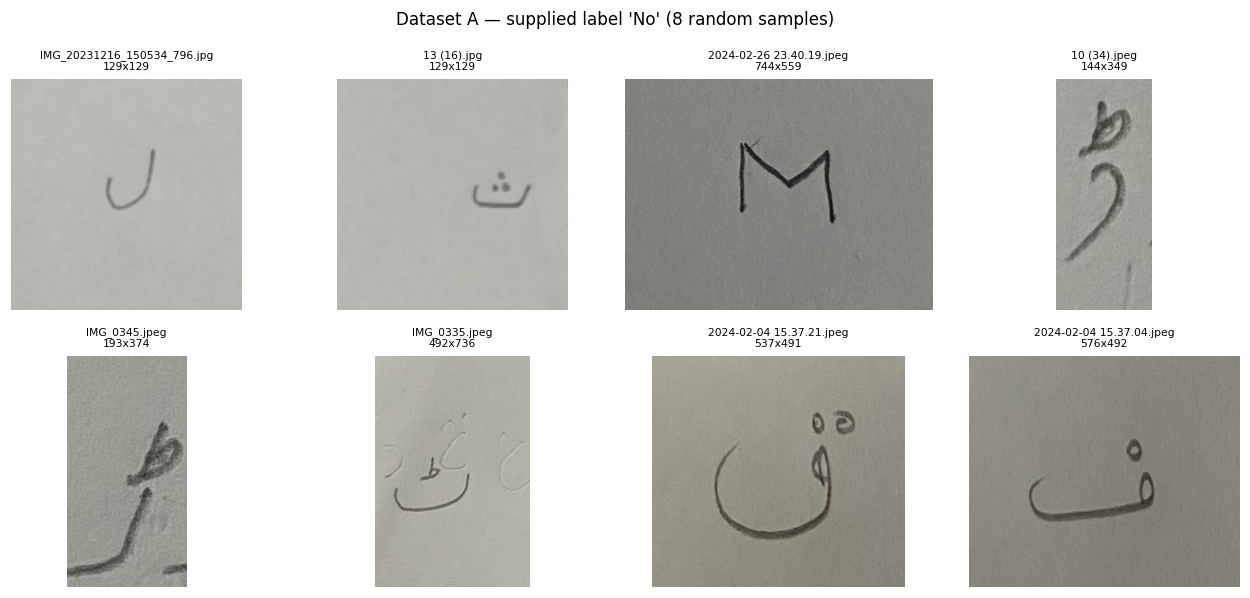

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_samples_class_No.png


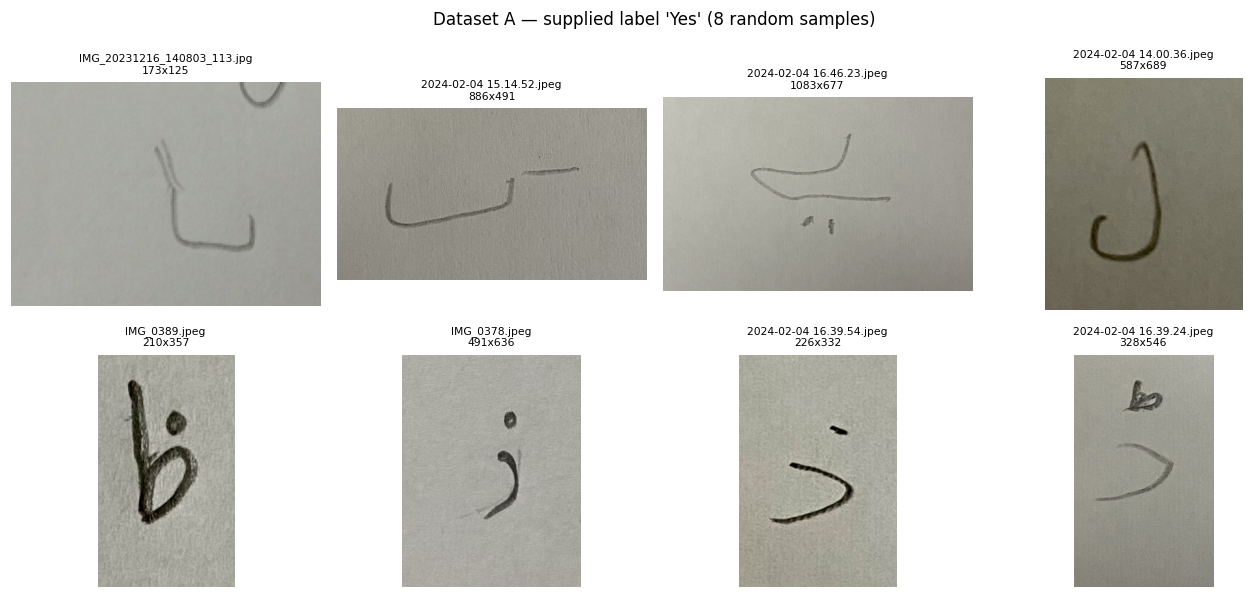

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_samples_class_Yes.png


In [ ]:
set_seed(SEED)

for label in sorted(df['class_label'].unique()):
    sample = df[df['class_label'] == label].sample(8, random_state=SEED)
    show_image_grid(
        paths   = list(sample['abs_path']),
        titles  = [f'{r.original_filename}\n{r.width}x{r.height}' for r in sample.itertuples()],
        nrow=2, ncol=4,
        suptitle=f"Dataset A — supplied label '{label}' (8 random samples)",
        filename=f'A_samples_class_{label}.png',
    )

### 4.2 Identical files carrying both labels

**This is the single most important figure in the notebook.**

Each pair below is the *same file* — identical SHA-256, identical bytes — stored in both the
`Yes` and `No` folders. No classifier can be right about both copies, and any evaluation that
puts one copy in train and the other in test is measuring memorisation.

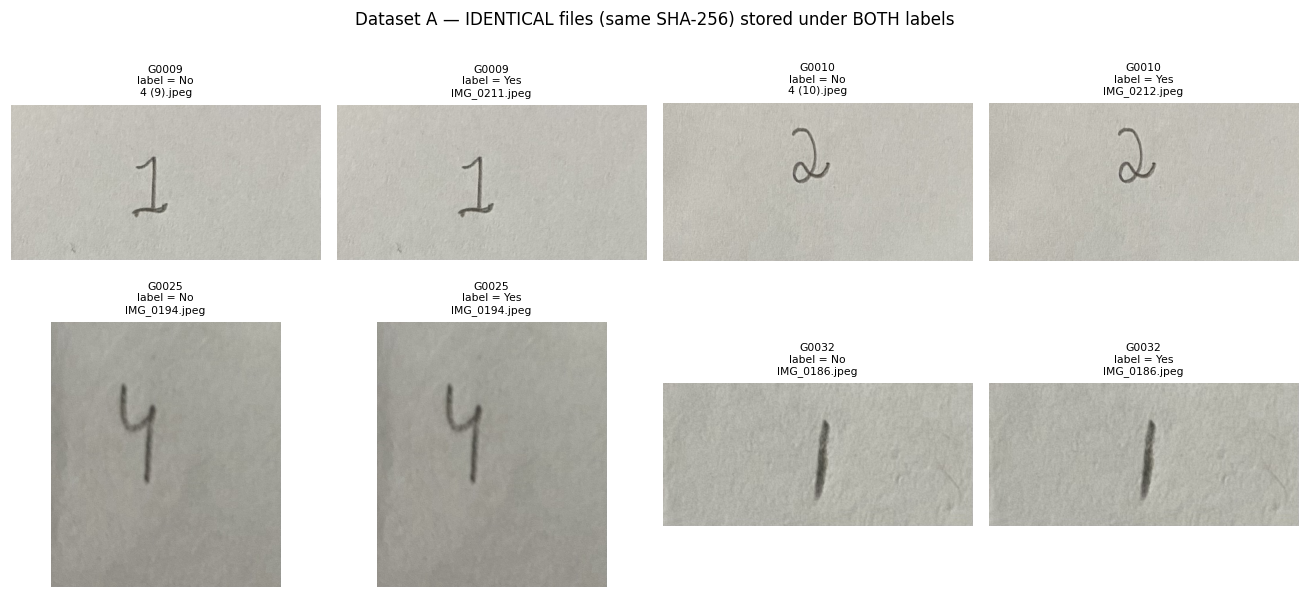

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_cross_class_conflicts.png


In [ ]:
conflicts = df[df['is_cross_class_conflict'] == 1].sort_values(['duplicate_group', 'class_label'])

paths, titles = [], []
for group in list(conflicts['duplicate_group'].unique())[:4]:
    sub = conflicts[conflicts['duplicate_group'] == group]
    # take one file from each distinct label in the group
    for label in sorted(sub['class_label'].unique()):
        r = sub[sub['class_label'] == label].iloc[0]
        paths.append(r['abs_path'])
        titles.append(f'{group}\nlabel = {r["class_label"]}\n{r["original_filename"]}')

show_image_grid(paths, titles, 2, 4,
                'Dataset A — IDENTICAL files (same SHA-256) stored under BOTH labels',
                'A_cross_class_conflicts.png')

### 4.3 Summary panel

Three questions, three panels:

1. **Does the 426/426 balance survive deduplication?**
2. **Are the images a consistent size?** (this drives our resizing decision later)
3. **How widespread is the duplication?**

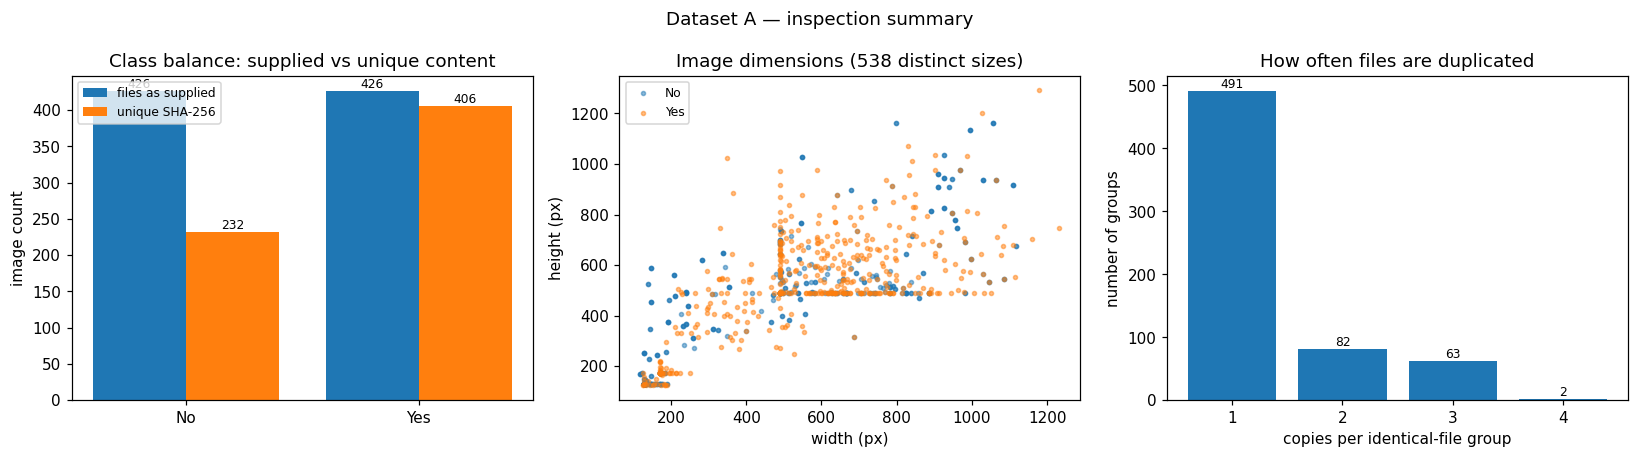

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_inspection_summary.png


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# --- Panel 1: supplied vs unique class counts -------------------------------
labels = list(supplied.index)
x = np.arange(len(labels))
ax[0].bar(x - 0.2, supplied.values, width=0.4, label='files as supplied')
ax[0].bar(x + 0.2, unique_only.reindex(labels).values, width=0.4, label='unique SHA-256')
ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_ylabel('image count')
ax[0].set_title('Class balance: supplied vs unique content')
ax[0].legend(fontsize=8)
for i, (a, b) in enumerate(zip(supplied.values, unique_only.reindex(labels).values)):
    ax[0].text(i - 0.2, a, str(a), ha='center', va='bottom', fontsize=8)
    ax[0].text(i + 0.2, b, str(b), ha='center', va='bottom', fontsize=8)

# --- Panel 2: image dimensions ----------------------------------------------
for label, sub in df.groupby('class_label'):
    ax[1].scatter(sub['width'], sub['height'], s=7, alpha=0.5, label=label)
ax[1].set_xlabel('width (px)'); ax[1].set_ylabel('height (px)')
ax[1].set_title(f'Image dimensions ({df.groupby(["width","height"]).ngroups} distinct sizes)')
ax[1].legend(fontsize=8)

# --- Panel 3: duplicate group sizes -----------------------------------------
hist = df.drop_duplicates('duplicate_group')['group_size'].value_counts().sort_index()
ax[2].bar(hist.index.astype(str), hist.values)
ax[2].set_xlabel('copies per identical-file group'); ax[2].set_ylabel('number of groups')
ax[2].set_title('How often files are duplicated')
for i, v in enumerate(hist.values):
    ax[2].text(i, v, str(v), ha='center', va='bottom', fontsize=8)

fig.suptitle('Dataset A — inspection summary', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_inspection_summary.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_inspection_summary.png"}')

---
## What we actually did

1. Mounted Drive, recorded exact library versions and fixed the random seed to 42.
2. Extracted the Dataset A archive into local disk, leaving the original archive untouched.
3. Located the class folders programmatically rather than hard-coding a path.
4. Read all 852 images, verifying that each one decodes without error.
5. Computed a SHA-256 fingerprint for every file to detect exact duplicates.
6. Extracted EXIF camera model and capture timestamp where available.
7. Built a master metadata table (one row per image) and saved it as the single source of
   truth for all later stages.
8. Produced an inspection report and four figures.

## What we learned

*(complete after running)*

- Files: 852. Corrupted: ___. Unique SHA-256 hashes: ___.
- Duplication is **not symmetric** between the two classes: ___
- Identical files stored under both labels: ___ files in ___ groups.
- True class balance after deduplication: Yes ___ / No ___.
- Images are single characters at ___ distinct pixel sizes — resizing is mandatory.
- EXIF capture dates give only ___ distinct session groups.

## Observations:

> Before any modelling, we audited the public dataset by fingerprinting every file.
> The supplied 426/426 class balance does not reflect 852 distinct handwriting samples.
> A number of files are exact byte-level copies, and a subset appears under **both** class
> labels simultaneously. We have therefore built a documented, deduplicated pilot version of
> the dataset, and we will report results on both the raw and cleaned versions so the effect
> of these issues is visible rather than hidden.

## Limitations recorded at this stage

| Limitation | Consequence |
|---|---|
| No participant IDs | A **writer-independent** split is impossible; we cannot claim one |
| No script labels | We cannot isolate Urdu-only performance |
| No per-image age | We cannot analyse by age group |
| Very few EXIF session groups | Grouped cross-validation is severely limited |
| Duplicates across classes | Some supplied labels are provably unreliable |

## Design requirements this generates for our own Urdu dataset

| Problem observed here | Requirement for our dataset |
|---|---|
| No participant ID | Assign `participant_id` at collection time, from day one |
| Unknown script | Record language/script explicitly per sample |
| Unknown writing task | Use a standardised, documented task sheet |
| Duplicate files | Hash every file on ingest; reject duplicates automatically |
| Contradictory labels | Labels attach to the **participant**, not to the folder |
| Inconsistent image sizes | Fix the capture protocol: distance, resolution, crop rule |


